In [1]:
from pathlib import Path
import os
import natsort
import mne

import seaborn as sns
import matplotlib.pyplot as plt

mne.set_log_level("CRITICAL")

sns.set()

Text(0.5, 0.98, 'right_hand')

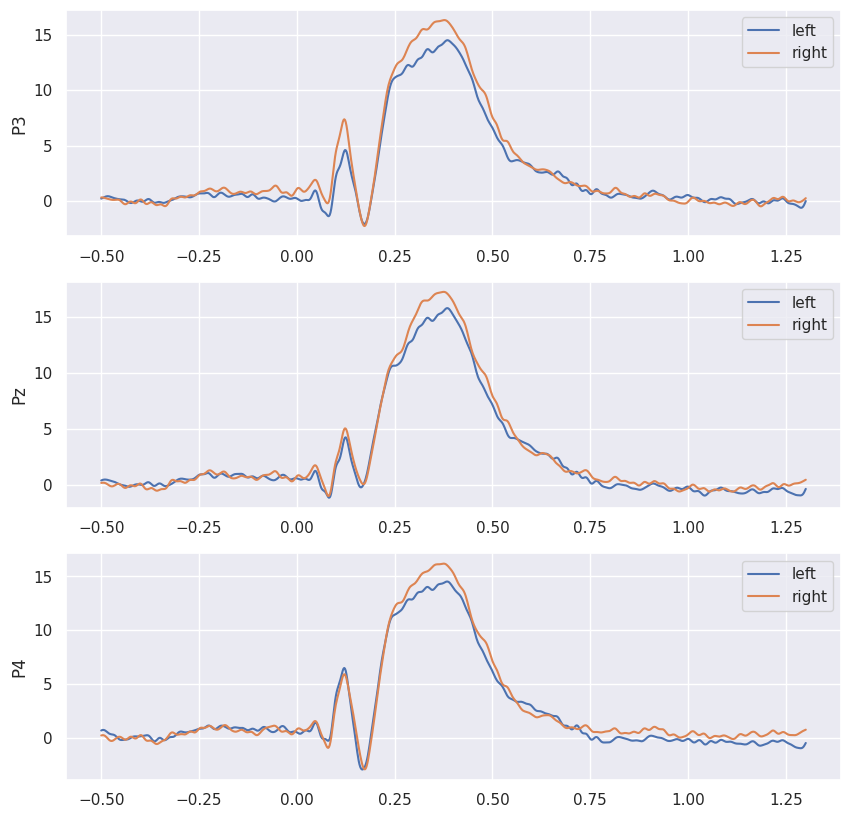

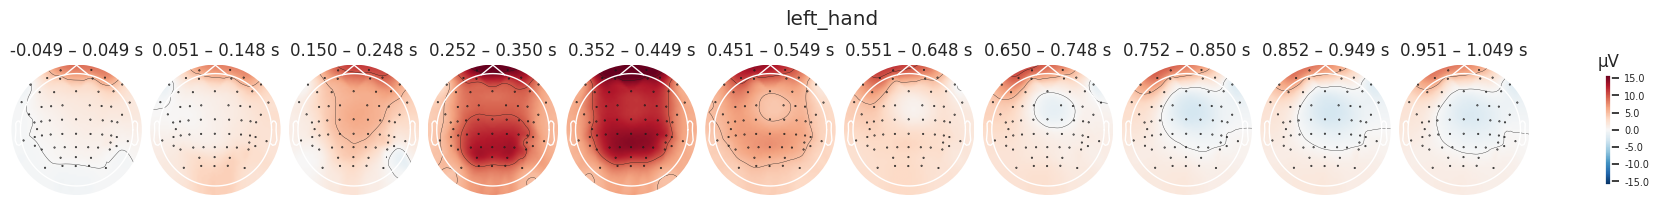

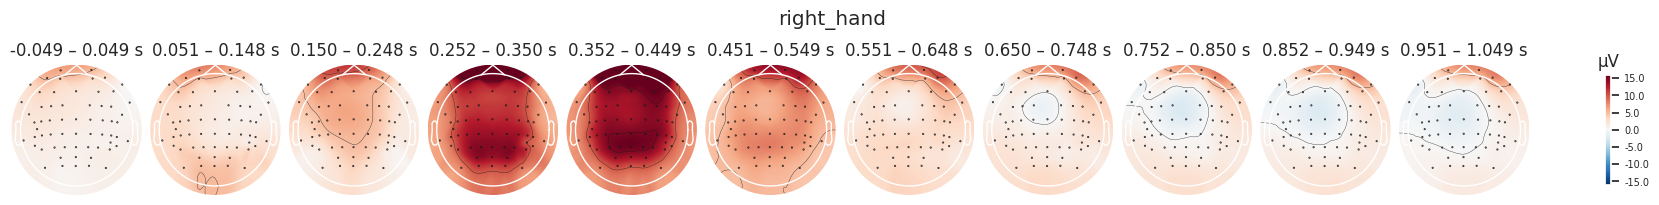

In [3]:

#dataset_name = "Dreyer2023"
dataset_name = "Lee2019_MI"

base = Path("../Dataset") / "evoked" / dataset_name

files = natsort.natsorted(os.listdir(base))
files

left_hand = [f for f in files if "left_hand" in f]
right_hand = [f for f in files if "right_hand" in f]

left_hand_evokeds_list = []
for f in left_hand:
    evoked_left = mne.read_evokeds(base / f)
    left_hand_evokeds_list.append(evoked_left[0])

right_hand_evokeds_list = []
for f in right_hand:
    evoked_right = mne.read_evokeds(base / f)
    right_hand_evokeds_list.append(evoked_right[0])

left_hand_evoked = mne.combine_evoked(left_hand_evokeds_list, weights="equal")
left_hand_evoked.crop(tmin=-0.5, tmax=1.3)

right_hand_evoked = mne.combine_evoked(right_hand_evokeds_list, weights="equal")
right_hand_evoked.crop(tmin=-0.5, tmax=1.3)

left = left_hand_evoked.get_data(picks="Pz", units="uV").squeeze()
right = right_hand_evoked.get_data(picks="Pz", units="uV").squeeze()

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].set_ylabel("P3")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="P3", units="uV").squeeze(), ax=ax[0],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="P3", units="uV").squeeze(), ax=ax[0],
             label="right")

ax[1].set_ylabel("Pz")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="Pz", units="uV").squeeze(), ax=ax[1],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="Pz", units="uV").squeeze(), ax=ax[1],
             label="right")

ax[2].set_ylabel("P4")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="P4", units="uV").squeeze(), ax=ax[2],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="P4", units="uV").squeeze(), ax=ax[2],
             label="right")

if dataset_name == "Dreyer2023":
    vlim = [-7.5, 7.5]
elif dataset_name == "Lee2019_MI":
    #vlim = [-7.5, 7.5]
    vlim = [-16, 16]

left_hand_evoked.info.set_montage("standard_1005")
im = left_hand_evoked.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], average=0.1,
                                   show=False, vlim=vlim)
im.suptitle("left_hand")

right_hand_evoked.info.set_montage("standard_1005")
im = right_hand_evoked.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], average=0.1,
                                    show=False, vlim=vlim)
im.suptitle("right_hand")


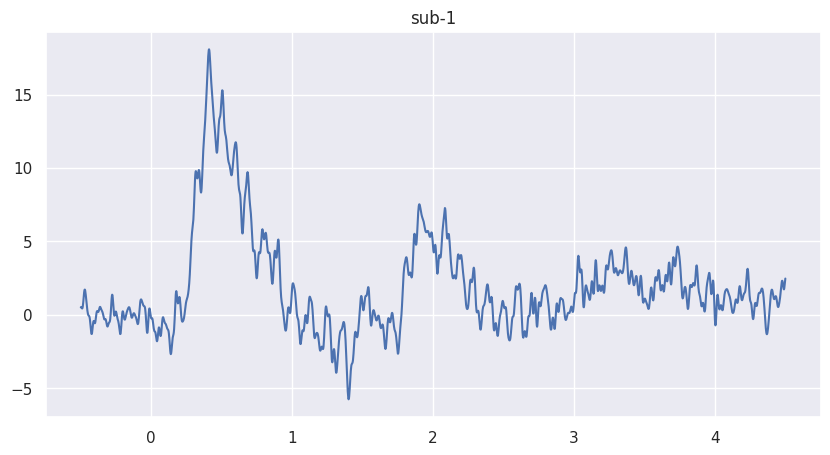

In [4]:
files = natsort.natsorted(os.listdir(base))
files

left_hand = [f for f in files if "left_hand" in f]
right_hand = [f for f in files if "right_hand" in f]

left_hand_evokeds_list = []
for idx, f in enumerate(left_hand):
    evoked_left = mne.read_evokeds(base / f)[0]
    #evoked_left[0].plot(picks="Pz", units="uV", show=False)
    evoked_left.crop(tmin=-0.5, tmax=4.5)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax = sns.lineplot(x=evoked_left.times, y=evoked_left.get_data(units="uV", picks="Pz").squeeze())
    ax.set_title(f'sub-{idx + 1}')
    break


/tmp/ipykernel_115318/565414542.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(8, 3))


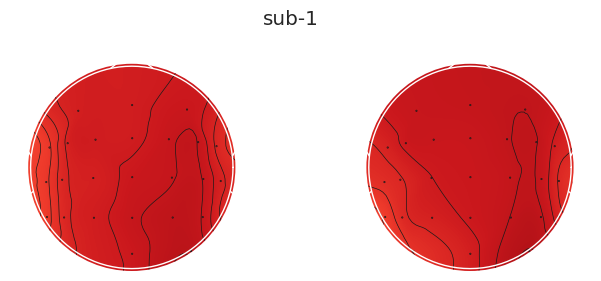

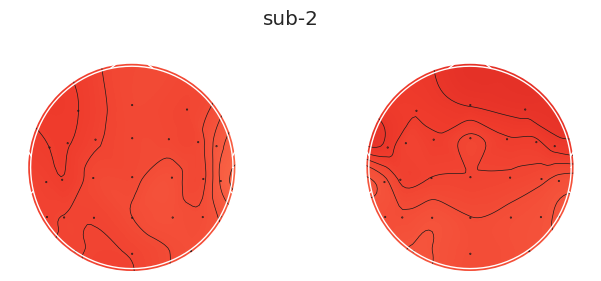

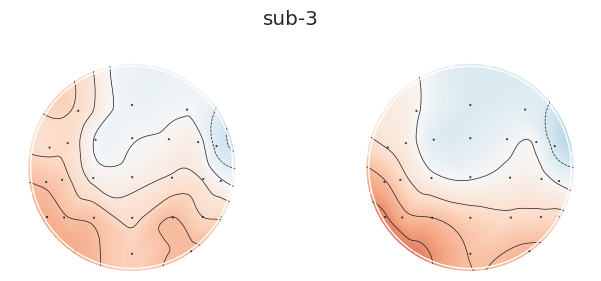

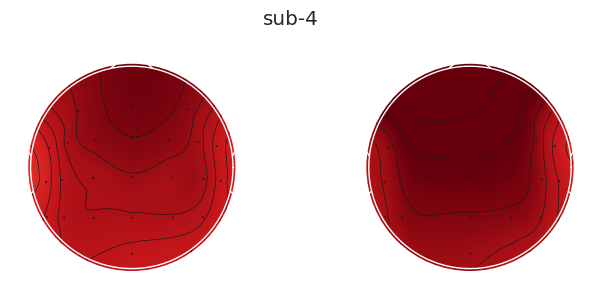

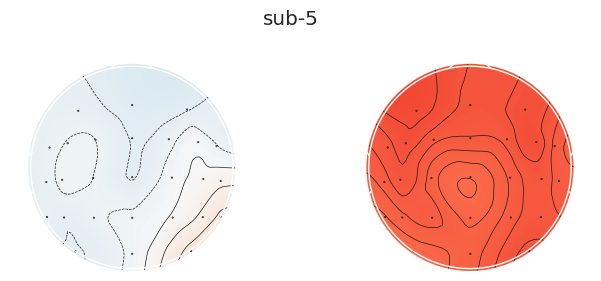

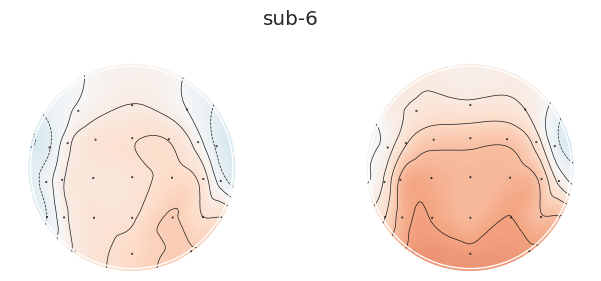

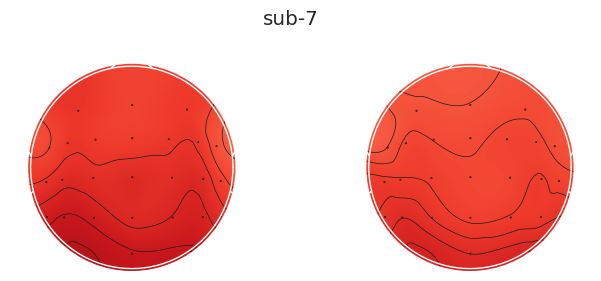

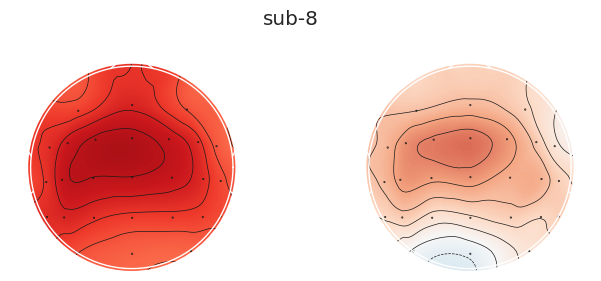

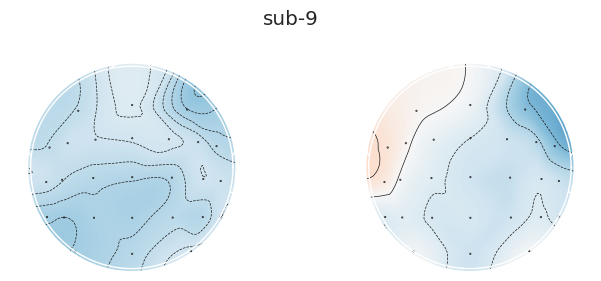

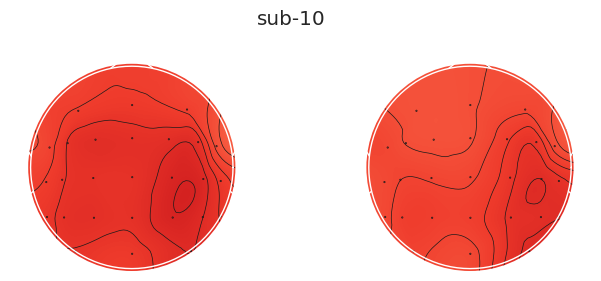

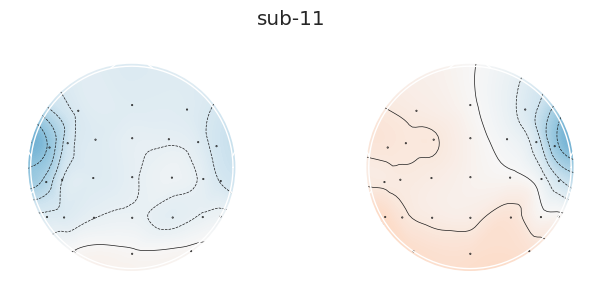

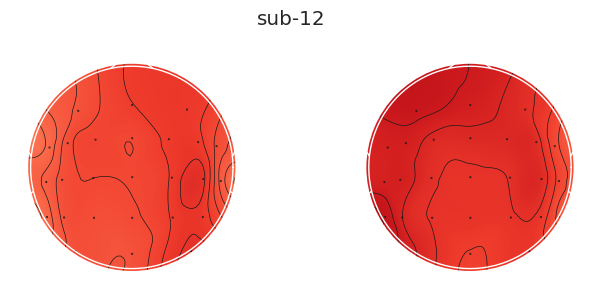

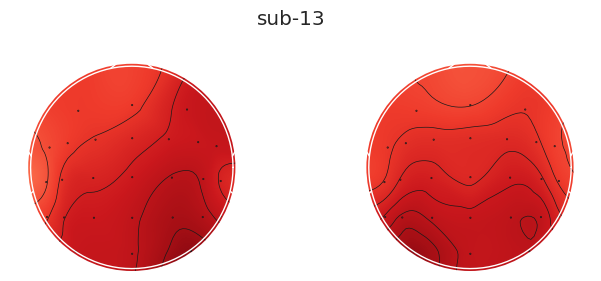

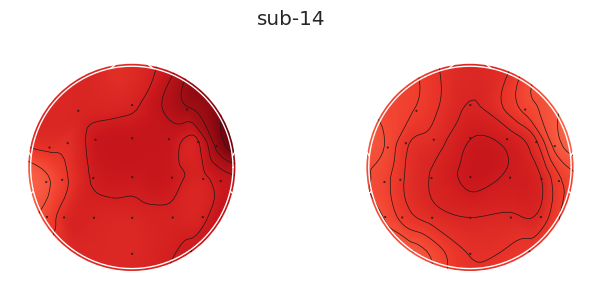

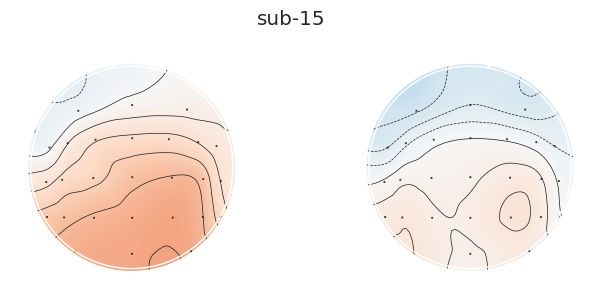

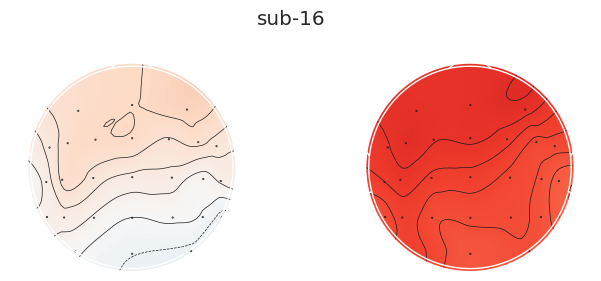

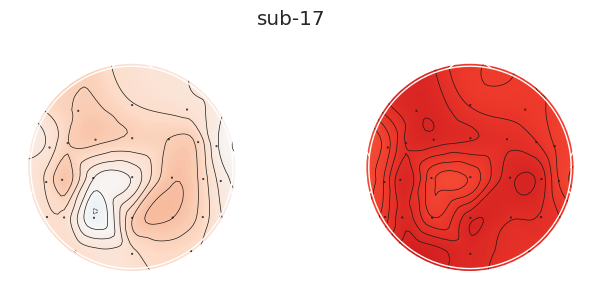

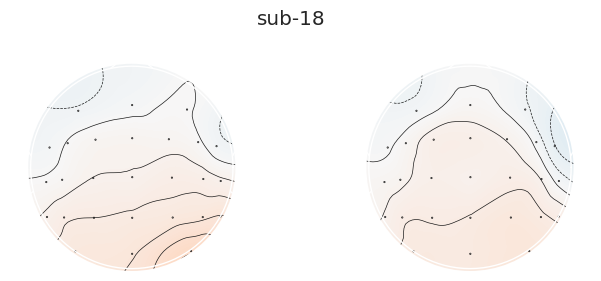

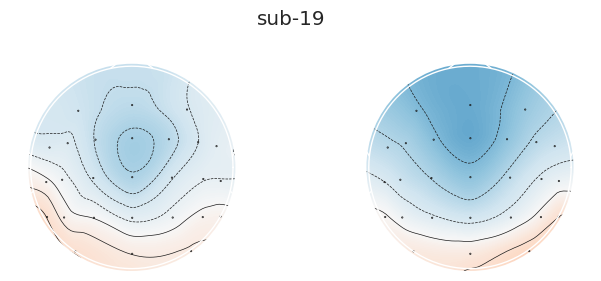

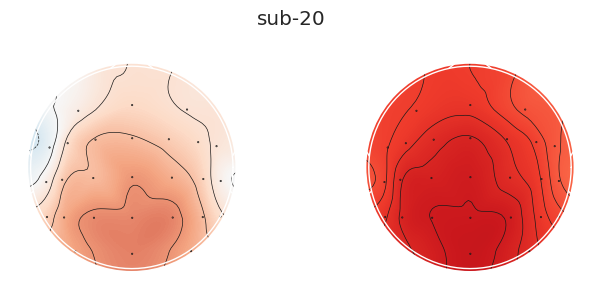

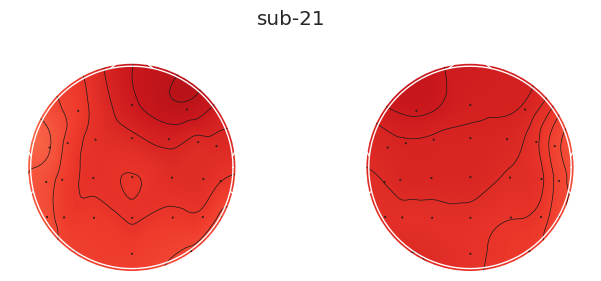

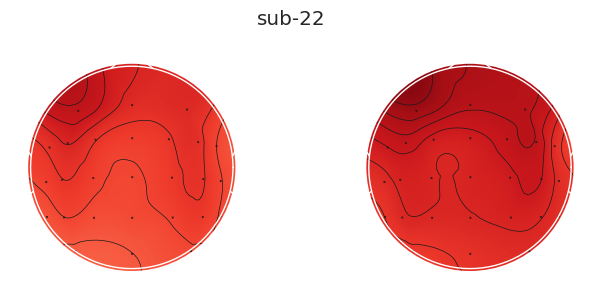

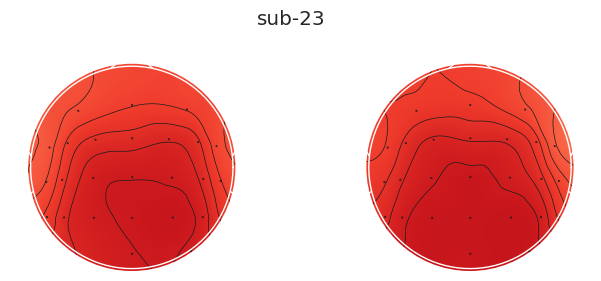

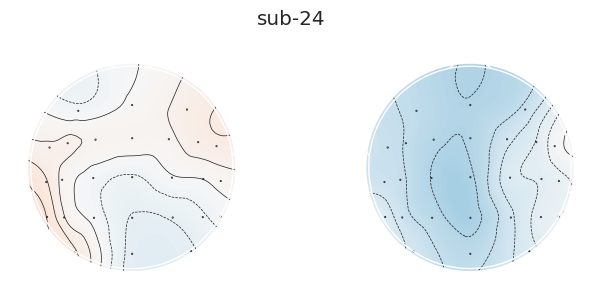

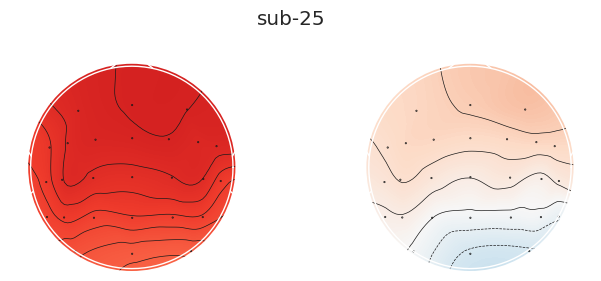

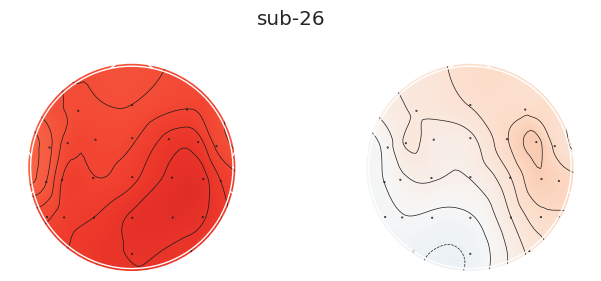

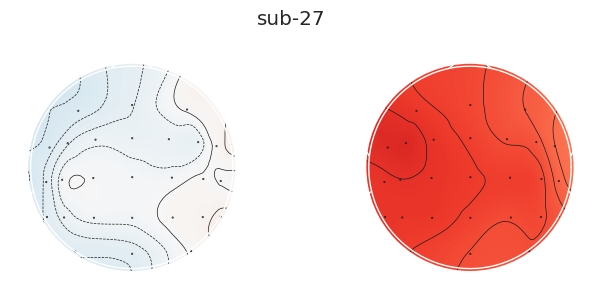

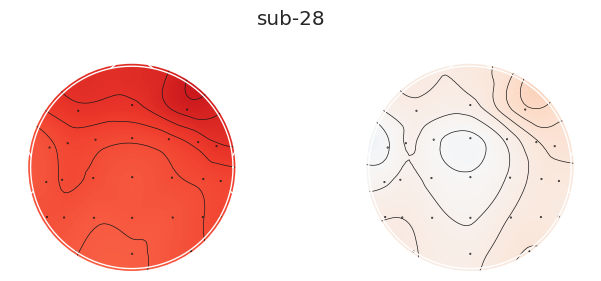

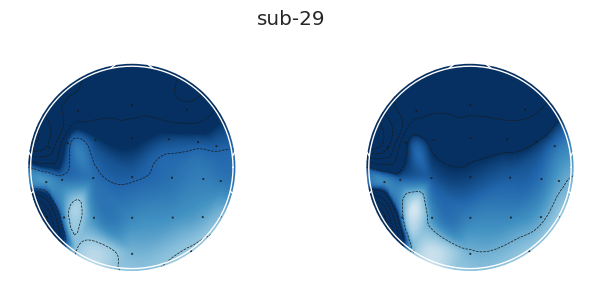

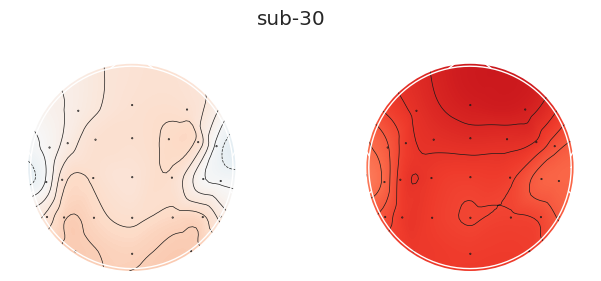

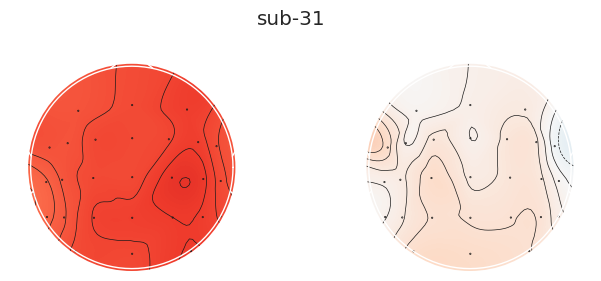

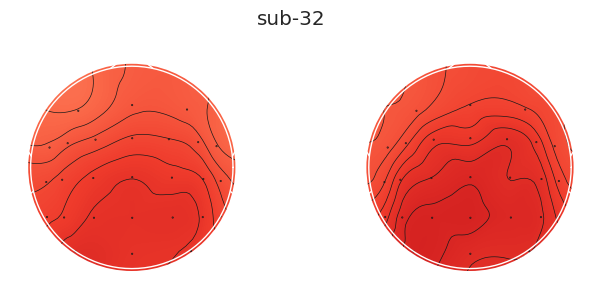

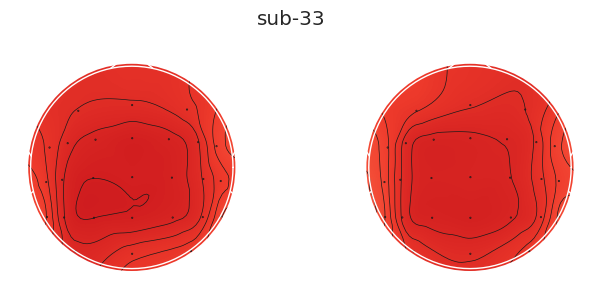

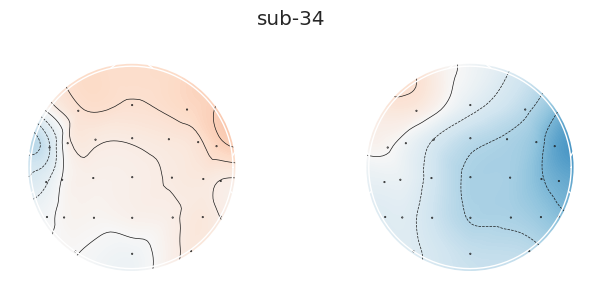

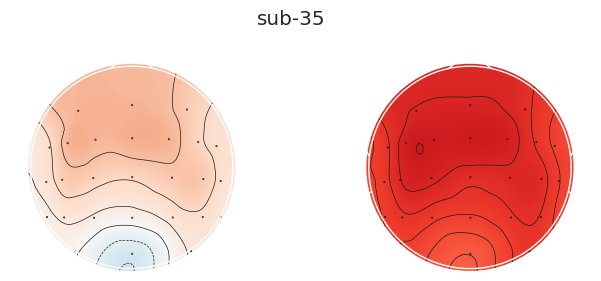

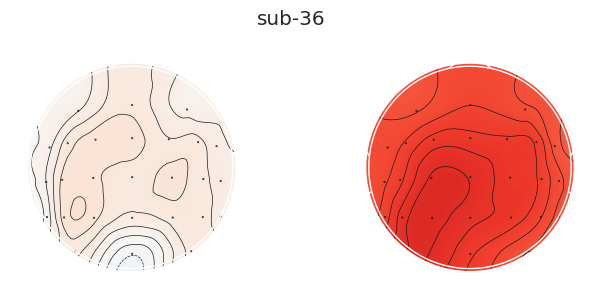

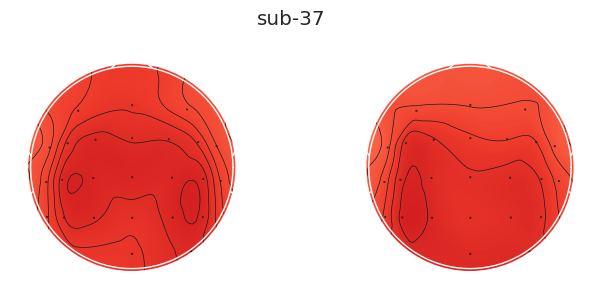

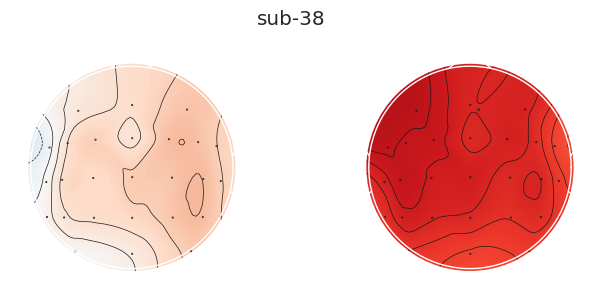

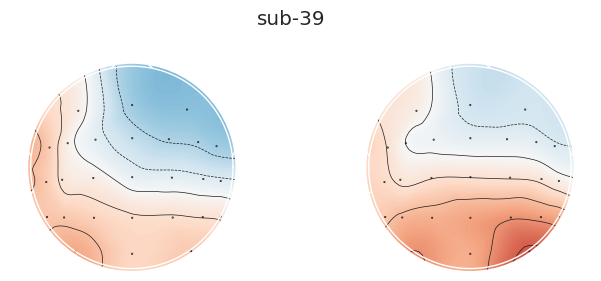

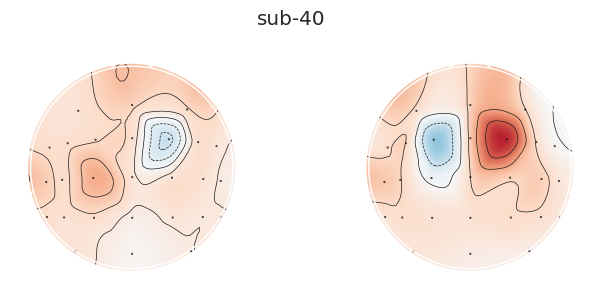

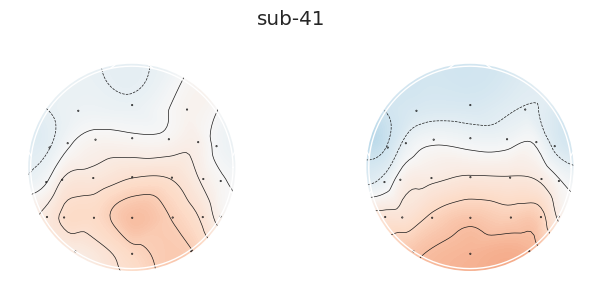

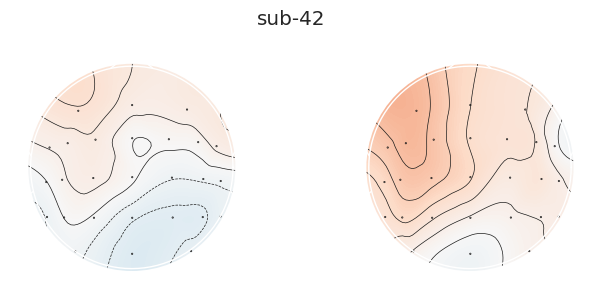

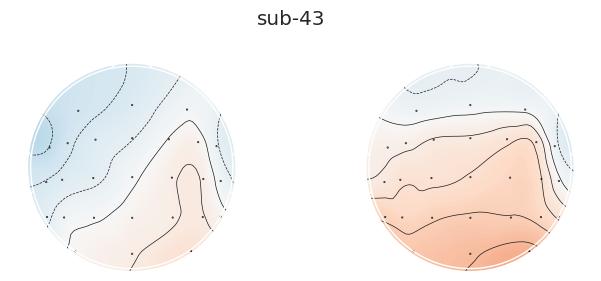

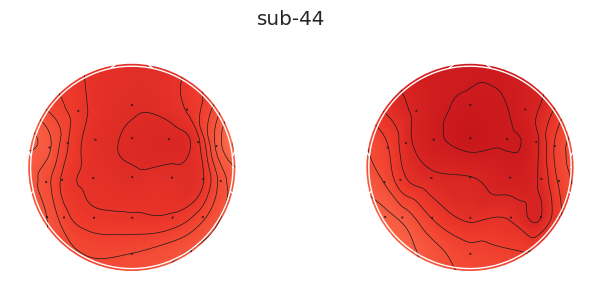

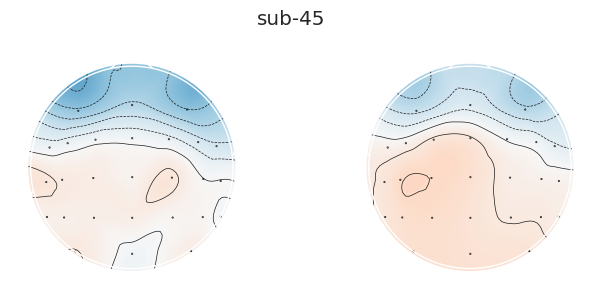

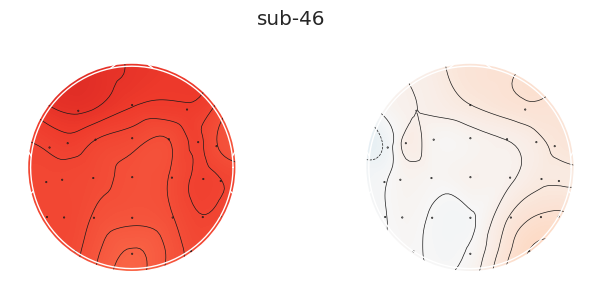

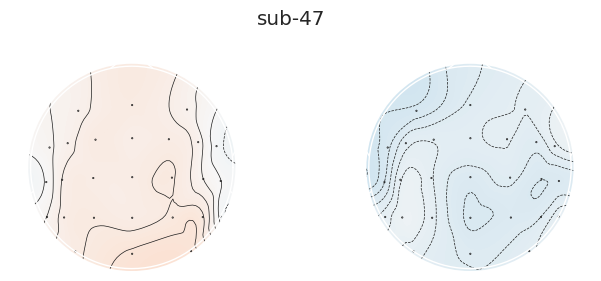

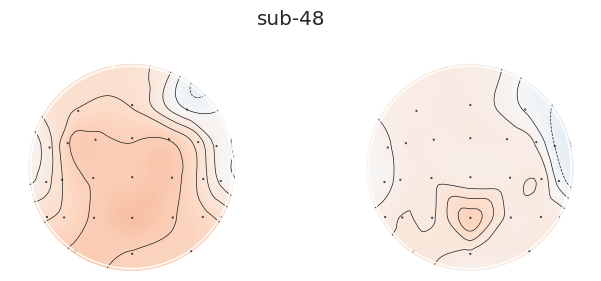

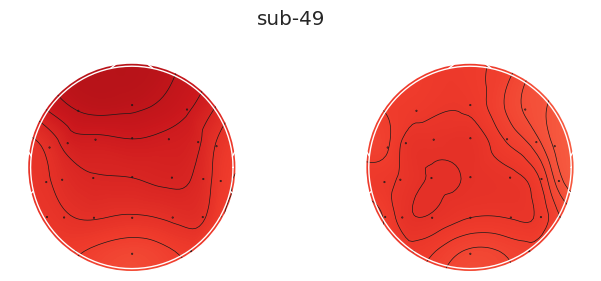

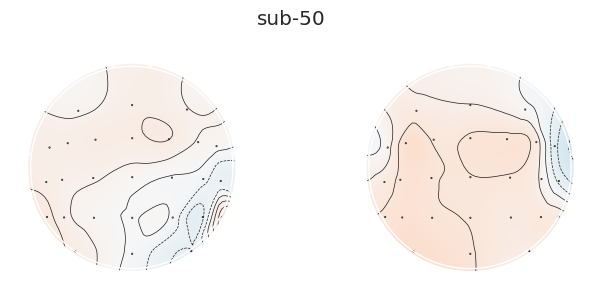

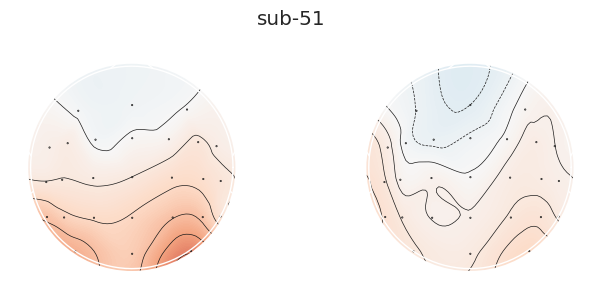

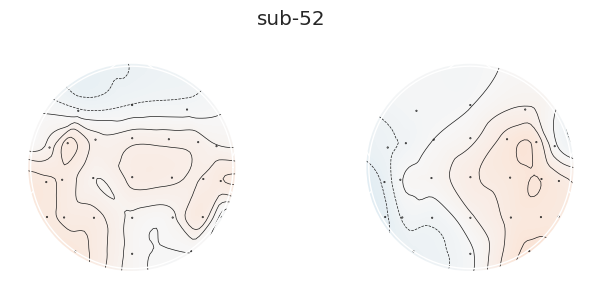

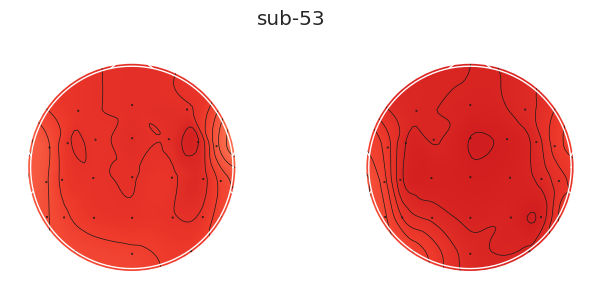

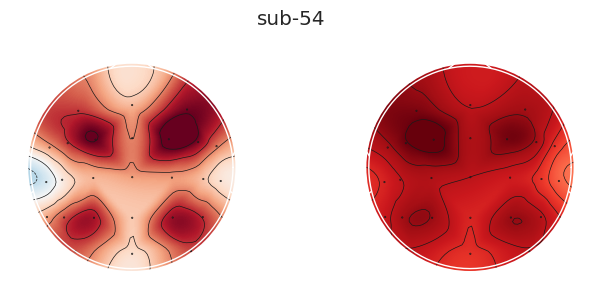

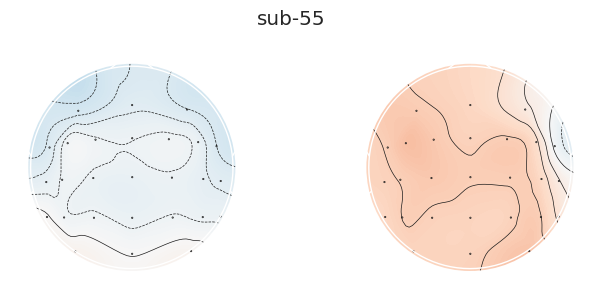

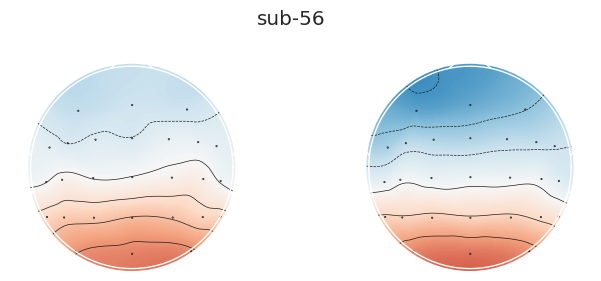

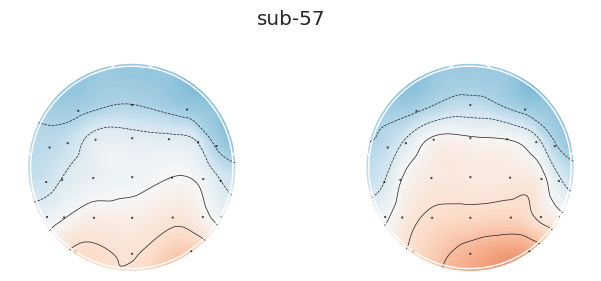

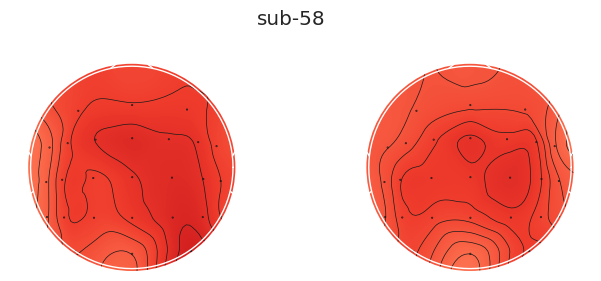

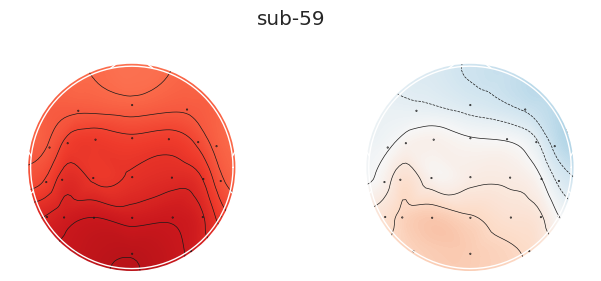

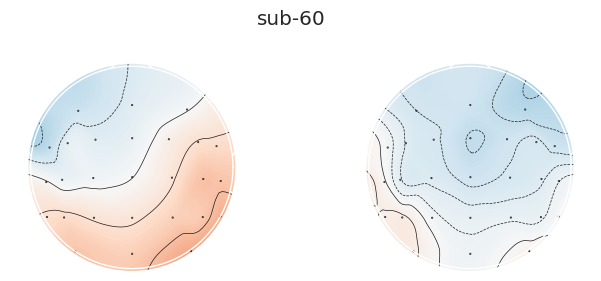

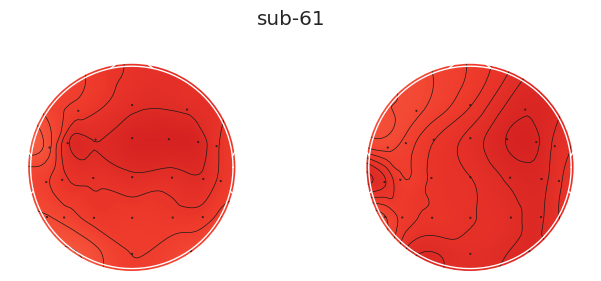

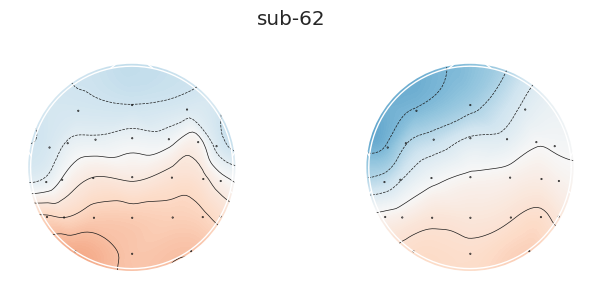

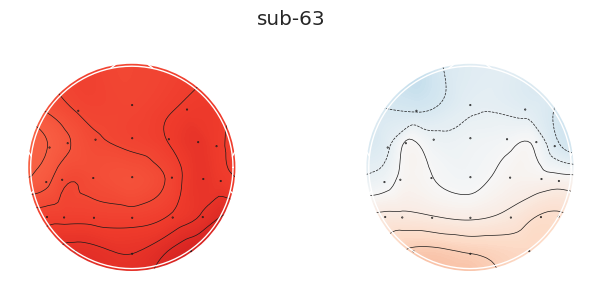

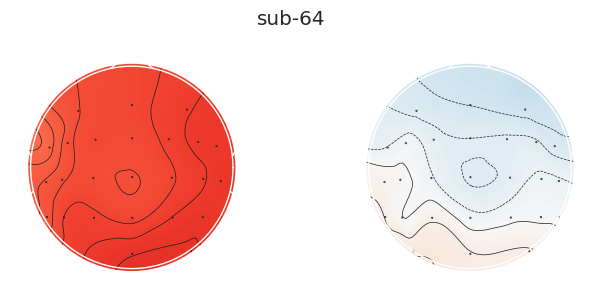

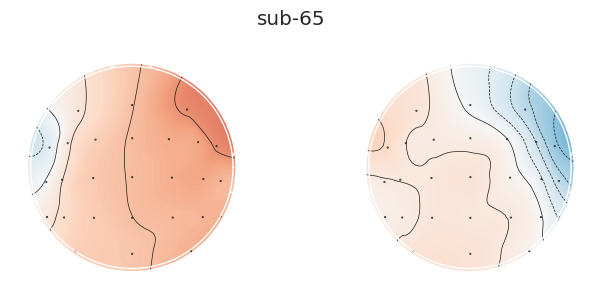

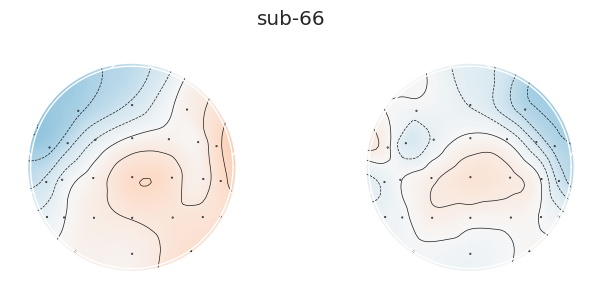

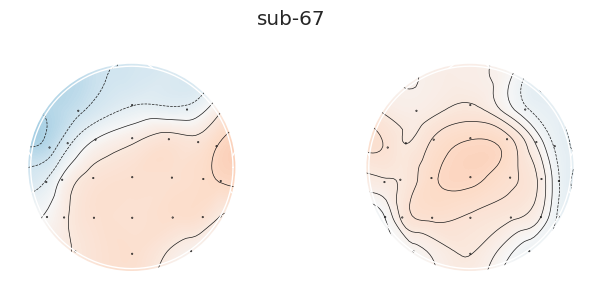

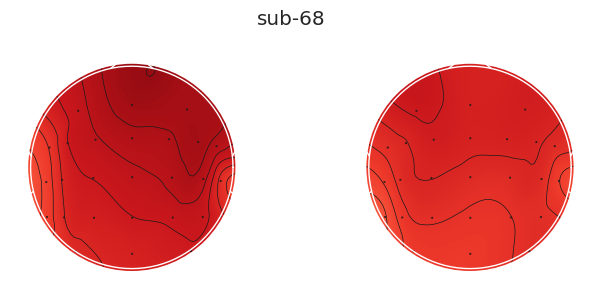

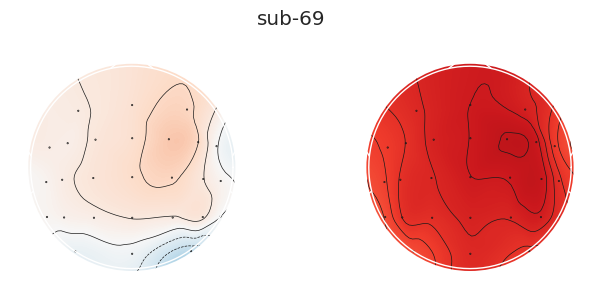

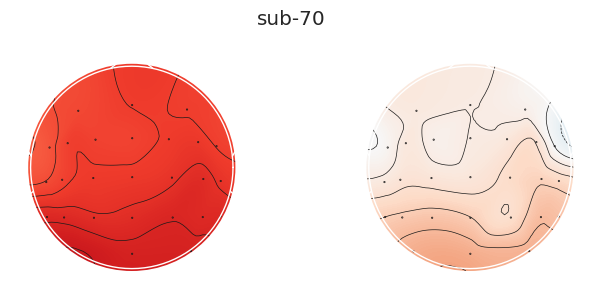

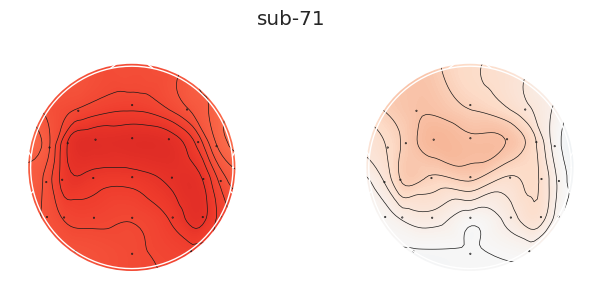

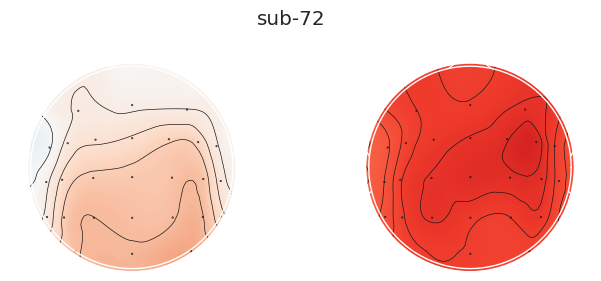

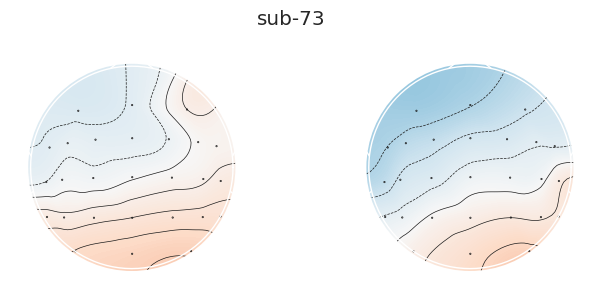

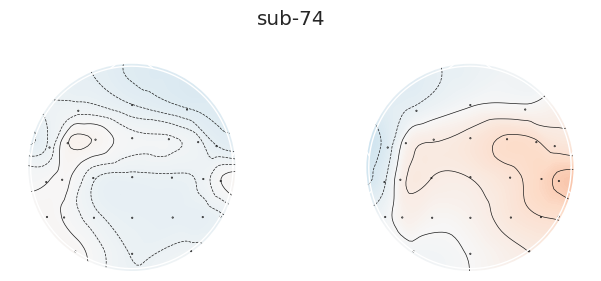

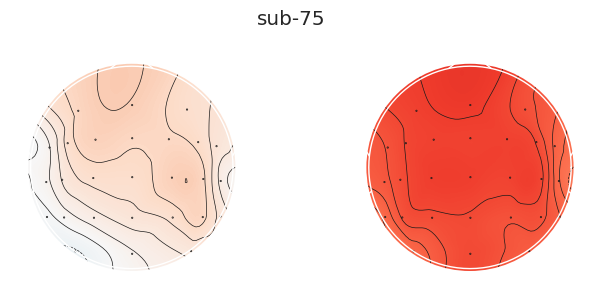

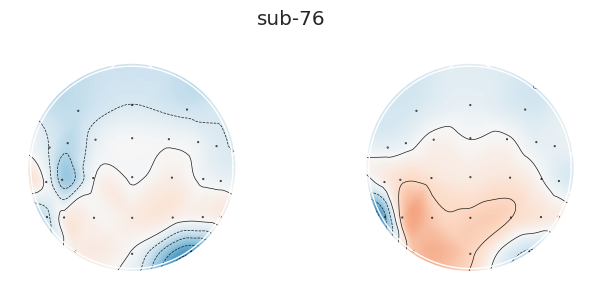

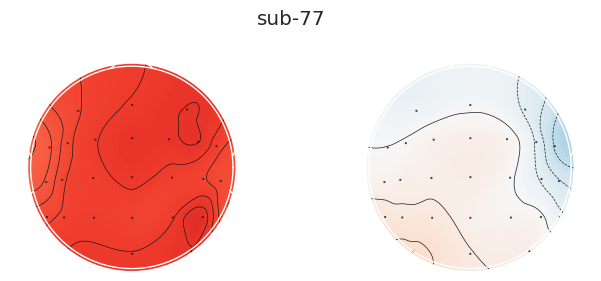

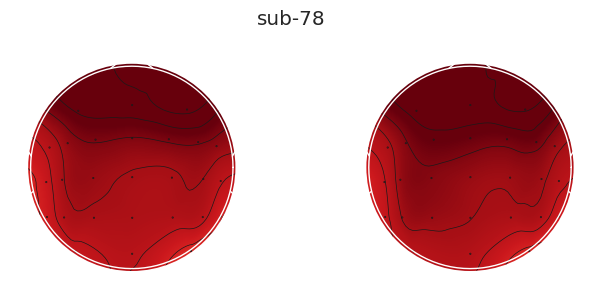

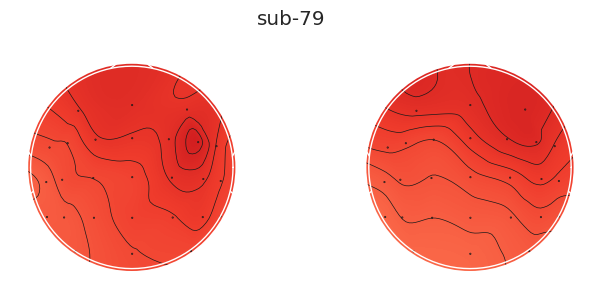

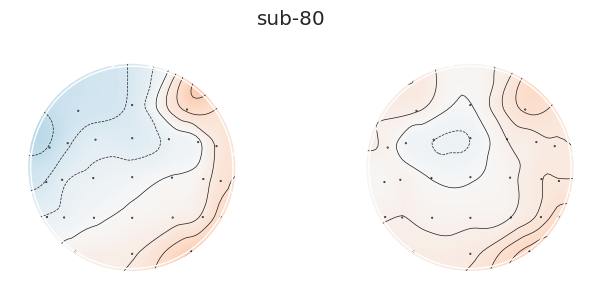

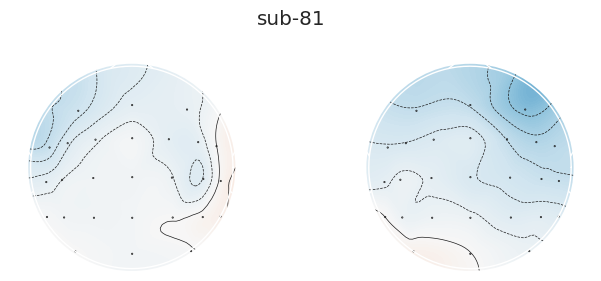

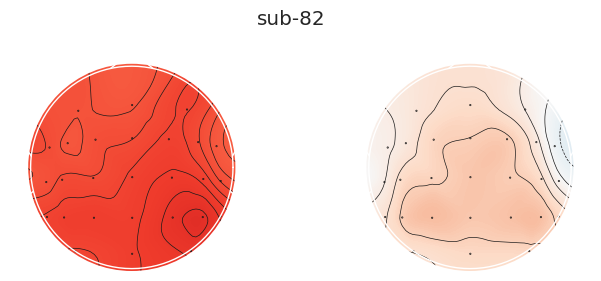

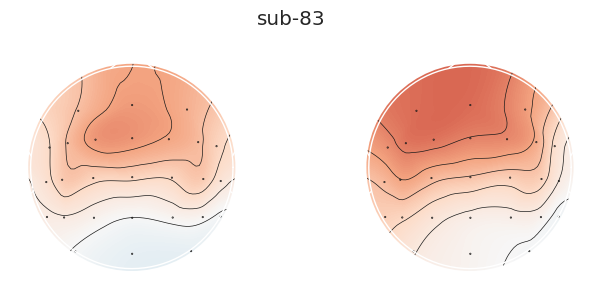

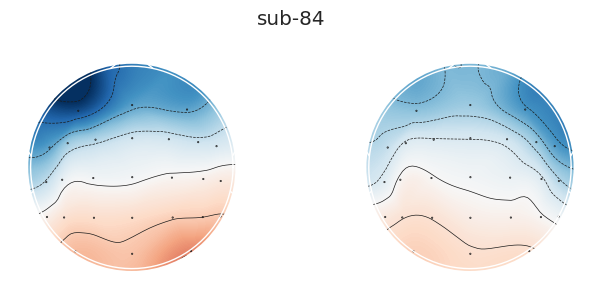

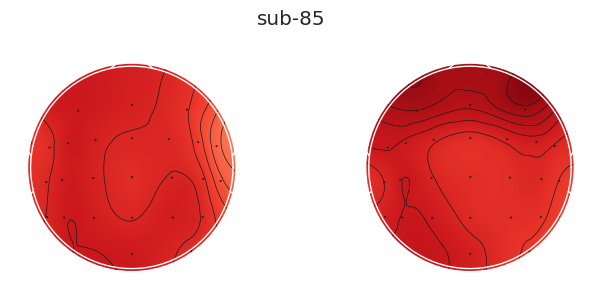

In [5]:
import numpy as np

for idx, (left, right) in enumerate(zip(left_hand, right_hand)):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    left = mne.read_evokeds(base / left)[0]
    right = mne.read_evokeds(base / right)[0]

    left.info.set_montage("standard_1005")
    right.info.set_montage("standard_1005")

    #left.plot_topomap(times=0.25, average=0.25, axes=axes[0], colorbar=False, show=False, sphere="auto")
    #right.plot_topomap(times=0.25, average=0.25, axes=axes[1], colorbar=False, show=False, extrapolate="local")

    info = mne.create_info(left.ch_names, 1000.0, "eeg")
    #info.set_montage("standard_1005")

    montage = mne.channels.make_standard_montage("standard_1005")
    ch_pos = montage.get_positions()["ch_pos"]
    ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in left.ch_names])

    im, _ = mne.viz.plot_topomap(left.get_data(tmin=0.0, tmax=0.5, units="uV").mean(1).squeeze(), ch_pos,
                                 axes=axes[0], show=False, vlim=[-10, 10])

    im, _ = mne.viz.plot_topomap(right.get_data(tmin=0.0, tmax=0.5, units="uV").mean(1).squeeze(), ch_pos,
                                 axes=axes[1], show=False, vlim=[-10, 10])

    fig.suptitle(f'sub-{idx + 1}')


